In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Collatz conjecture: counting steps [1]
- Copy the Collatz code discussed in class and modify it to  count the number of steps
required for a given integer to reach 1. Using this code, compute the number of steps
for all integers from 1 to 100 and plot the number of steps as a function of the starting
integer.

In [3]:
def collatz(n, max_iter = 1000):
   # print("Collatz simulation for number", n, end = " ---> ")
    step_number = 0
    for i in range (max_iter):
        if n == 1:
           # print(int(n), ' STOP')
            
            break
        else:
            if n%2 == 0:
                n = n/2
                step_number = step_number + 1
            else:
                n = 3*n + 1   
                step_number = step_number + 1
            #print(int(n), end =" ---> ")    
   # print('Number of steps of given integer to reach 1 = ', step_number)
    return step_number

In [4]:
starting_number = 1
last_number = 101
step_size = 1

array = np.arange(starting_number, last_number, step_size)
number_of_steps = []
for i in array:
    c = collatz(i)
    number_of_steps.append(c)
print (array)
print (number_of_steps)

[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100]
[0, 1, 7, 2, 5, 8, 16, 3, 19, 6, 14, 9, 9, 17, 17, 4, 12, 20, 20, 7, 7, 15, 15, 10, 23, 10, 111, 18, 18, 18, 106, 5, 26, 13, 13, 21, 21, 21, 34, 8, 109, 8, 29, 16, 16, 16, 104, 11, 24, 24, 24, 11, 11, 112, 112, 19, 32, 19, 32, 19, 19, 107, 107, 6, 27, 27, 27, 14, 14, 14, 102, 22, 115, 22, 14, 22, 22, 35, 35, 9, 22, 110, 110, 9, 9, 30, 30, 17, 30, 17, 92, 17, 17, 105, 105, 12, 118, 25, 25, 25]


Text(0, 0.5, 'number of steps')

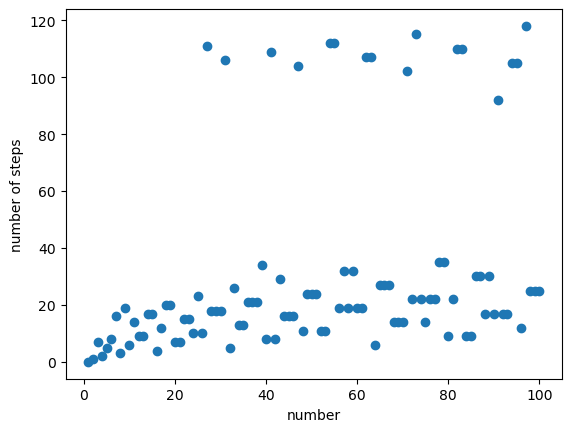

In [5]:
plt.scatter(array, number_of_steps)
plt.xlabel('number')
plt.ylabel('number of steps')

## 2. Histogram without built-in functions [2]
- Use the NumPy function np.random.normal(0, 1, N) to generate an array of N random
numbers drawn from a normal distribution, where N is a large integer. Construct a
histogram of this data without using plt.hist or any other built-in histogram functions.
Divide the data range into bins, count the number of values in each bin using loops and
conditional statements, and plot the histogram using a bar plot (plt.bar).

<BarContainer object of 50 artists>

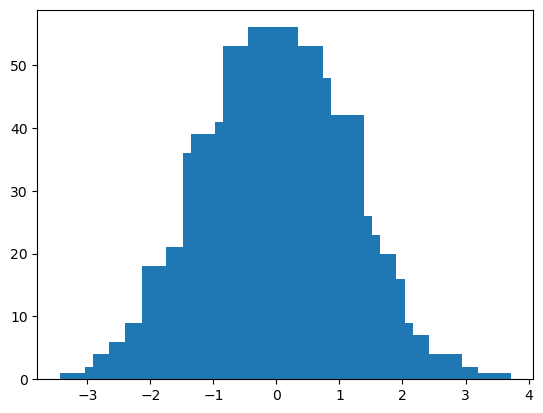

In [28]:
N = 1000
a = np.random.normal(0,1,N)
# dividing bins
number_of_bins = 50
minimum = np.min(a)
maximum = np.max(a)
#print(minimum, maximum)
bins = np.linspace(minimum, maximum, number_of_bins + 1)
#print(bins)
counts = [0] * number_of_bins

for i in a:
    for j in range(number_of_bins):
        if bins[j] <= i < bins[j+1]:
            counts[j] = counts[j] + 1
            break
        elif j == number_of_bins-1 and i == bins[j+1]:
            counts[j] = counts[j] + 1
bin_center = bins[:-1] + bin_width/2
plt.bar(bin_center, counts)

## 3. Mean, median, and standard deviation of an array [3]
- For a given array of numbers, write a Python function that returns the mean, median, and
standard deviation of the array. Do not use NumPy or any built-in statistical functions.
Your implementation should use only loops and conditional statements. Test your func-
tion using both a manually defined array and a randomly generated array as in problem
2 above.

In [21]:
def statistics(x_array):
    # mean
    mean = np.sum(x_array)/len(x_array)    
     
    # median
    np.sort(x_array)
    k = int(len(x_array)//2) 
    median = x_array[k]
   
    # standard deviation of the given data
    sums = 0
    n = len(x_array)
    # mean of the given data
    
    mean_square = np.sum(x_array**2)/len(x_array)   
    variance = mean_square - mean**2
    standard_deviation = np.sqrt(variance)
    return mean, median, standard_deviation, variance

In [22]:
x = np.arange(1, 100)
print(statistics(x))
print(np.mean(x),np.median(x),np.std(x),np.var(x))

(np.float64(50.0), np.int64(50), np.float64(28.57738033247041), np.float64(816.6666666666665))
50.0 50.0 28.577380332470412 816.6666666666666


## 4. One-dimensional random walk simulation [4]
- A one-dimensional random walk starts at position x = 0. At each step, the walker moves
either +1 or−1 with equal probability. Write a Python function to simulate this random
walk for a given number of steps. Repeat the simulation many times and calculate the
average final position ⟨x⟩and the average of the square of the final position ⟨x2⟩. Find
how these quantities depend on the number of steps.

In [18]:
def simulate_random_walk(number_of_steps):
    position = 0
    steps = np.random.randint(-1,2,size = number_of_steps)
    position = np.sum(steps)
    return position

def run_simulations(number_of_steps, number_of_simulations):
    final_position = []
    for i in range(number_of_steps):
        final_position.append(simulate_random_walk(number_of_steps))

    average_final_position = np.mean(final_position)
    average_squared_final_position = np.mean(np.array(final_position)**2)

    return average_final_position, average_squared_final_position

In [17]:
number_of_steps_list = [10, 100, 1000, 10000]
number_of_simulations = 10000

result = []
for number_of_steps in number_of_steps_list:
    avg_x = run_simulations(number_of_steps, number_of_simulations)
    result.append({
    

np.int64(-1)